In [1]:
"""
Olist Delivery Performance Analysis
====================================
Investigation into the relationship between delivery performance
and customer review scores on the Olist Brazilian e-commerce platform.

This notebook executes the SQL queries in ../queries/ against the
Olist SQLite database and visualises the findings.
"""

import sqlite3
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# Paths
# ---------------------------------------------------------------
# The notebook lives in notebooks/, so we step up one directory
# to find the project root, then resolve data and queries from there.
PROJECT_ROOT = Path.cwd().parent
DB_PATH = PROJECT_ROOT / "data" / "olist.sqlite"
QUERIES_DIR = PROJECT_ROOT / "queries"
FIGURES_DIR = PROJECT_ROOT / "figures"

# Verify everything is where we expect
assert DB_PATH.exists(), f"Database not found at {DB_PATH}"
assert QUERIES_DIR.exists(), f"Queries directory not found at {QUERIES_DIR}"
FIGURES_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------------
# Database connection
# ---------------------------------------------------------------
conn = sqlite3.connect(DB_PATH)

# ---------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------
def run_query(query_filename: str) -> pd.DataFrame:
    """
    Read a .sql file from the queries directory and execute it
    against the Olist database, returning results as a DataFrame.
    
    This keeps the notebook focused on analysis and visualisation
    while the SQL itself remains in version-controlled .sql files.
    """
    sql_path = QUERIES_DIR / query_filename
    with open(sql_path, "r", encoding="utf-8") as f:
        query = f.read()
    return pd.read_sql_query(query, conn)


# ---------------------------------------------------------------
# Plot styling
# ---------------------------------------------------------------
# Clean, readable defaults that work on GitHub's white background
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 100,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

print(f"Connected to: {DB_PATH.name}")
print(f"Queries available: {sorted(p.name for p in QUERIES_DIR.glob('*.sql'))}")

Connected to: olist.sqlite
Queries available: ['01_delivery_score_baseline.sql', '02_category_variation.sql', '03_distance_confounder.sql', '04_seller_size_interaction.sql', '05_intervention_priorities.sql']


## 1. Does delivery delay actually move review scores?

We bucket every delivered order by how late or early it arrived relative to Olist's estimated delivery date, then average the review score per bucket. The hypothesis: the relationship is sharply non-linear, early and on-time deliveries cluster around the same score, while late deliveries collapse review scores severely.

In [2]:
# Load and display the result table
df1 = run_query("01_delivery_score_baseline.sql")
df1

,delay_bucket,n_orders,avg_review_score,pct_one_star,pct_five_star
0,1. Very early (15+ days),29624,4.32,6.7,64.2
1,2. Early (1-14 days),57572,4.28,6.5,61.7
2,3. On time,2748,4.10,8.0,53.1
3,4. Slightly late (1-7 days),3612,2.71,41.4,23.9
4,5. Late (8-30 days),2466,1.65,70.6,6.2
5,6. Very late (30+ days),331,2.05,63.1,13.6


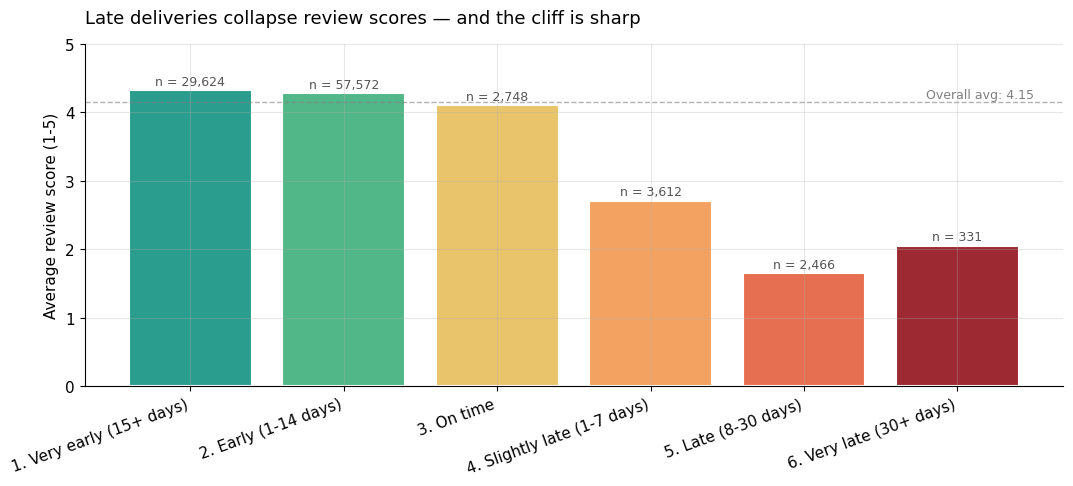

In [3]:
# Visualise: average review score per delay bucket
fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.bar(
    df1["delay_bucket"],
    df1["avg_review_score"],
    color=["#2a9d8f", "#52b788", "#e9c46a", "#f4a261", "#e76f51", "#9d2933"],
    edgecolor="white",
    linewidth=1.5,
)

# Annotate each bar with its sample size
for bar, n in zip(bars, df1["n_orders"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.08,
        f"n = {n:,}",
        ha="center",
        fontsize=9,
        color="#555",
    )

# Reference line at the dataset's overall average score
overall_avg = (df1["avg_review_score"] * df1["n_orders"]).sum() / df1["n_orders"].sum()
ax.axhline(overall_avg, color="grey", linestyle="--", linewidth=1, alpha=0.6)
ax.text(5.5, overall_avg + 0.05, f"Overall avg: {overall_avg:.2f}",
        ha="right", fontsize=9, color="grey")

ax.set_ylabel("Average review score (1-5)")
ax.set_title("Late deliveries collapse review scores — and the cliff is sharp",
             fontsize=13, pad=15, loc="left")
ax.set_ylim(0, 5)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "01_delay_vs_score.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:** The penalty cliff is at day zero, not gradual. Crossing the estimated delivery date by even one day drops the average review score by 1.4 stars, and 41% of slightly late orders receive a 1-star review.

## 2. Does the delivery-delay penalty vary by product category?

Late deliveries hurt review scores everywhere, but not equally. We restrict to the top 10 categories by order volume and compare the average review score for on-time vs late deliveries within each. The hypothesis: time-sensitive emotional categories (toys, gifts, sports) are punished more harshly than mundane household categories (bedding, telephony, furniture) because the underlying purchase has higher emotional stakes.

In [4]:
df2 = run_query("02_category_variation.sql")
df2

,category,avg_score_ontime,avg_score_late,score_drop_when_late,n_ontime,n_late
0,toys,4.38,2.14,2.24,3524,232
1,sports_leisure,4.38,2.17,2.21,7009,487
2,watches_gifts,4.28,2.21,2.07,5044,396
3,housewares,4.31,2.26,2.06,5377,299
4,health_beauty,4.39,2.35,2.04,7978,637
5,auto,4.30,2.31,1.99,3515,274
6,computers_accessories,4.20,2.28,1.93,6110,409
7,bed_bath_table,4.15,2.23,1.93,8508,679
8,furniture_decor,4.20,2.33,1.87,5784,438
9,telephony,4.18,2.43,1.75,3769,287


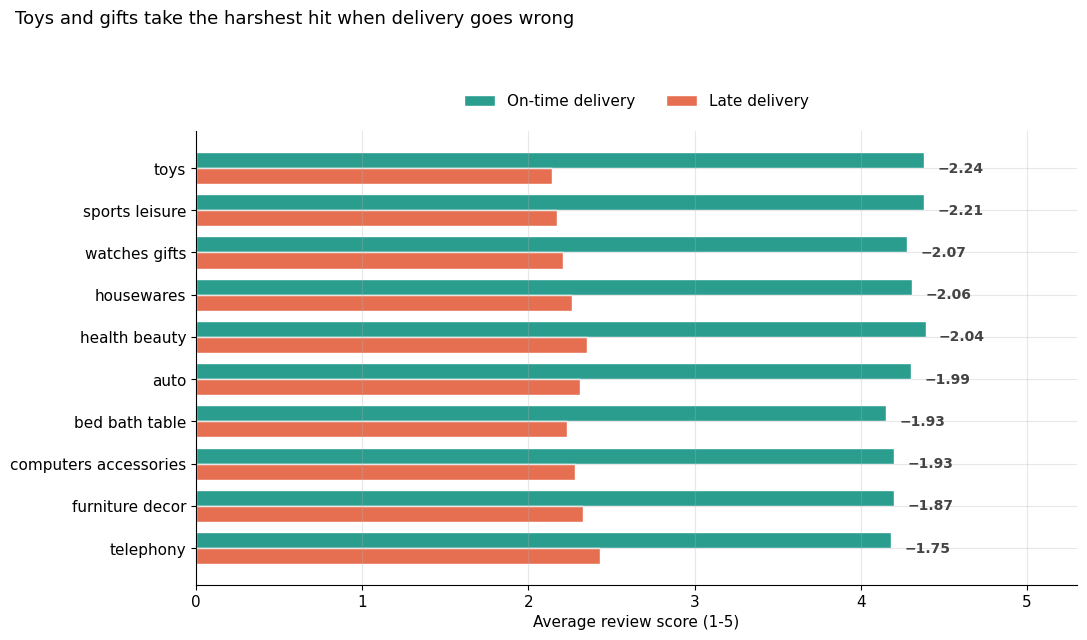

In [7]:
# Visualise: paired bars showing on-time vs late score per category,
# sorted by the size of the score drop.

fig, ax = plt.subplots(figsize=(11, 6.5)) 

df2_sorted = df2.sort_values("score_drop_when_late", ascending=True)

y_pos = range(len(df2_sorted))
bar_height = 0.38

ax.barh(
    [y + bar_height / 2 for y in y_pos],
    df2_sorted["avg_score_ontime"],
    height=bar_height,
    color="#2a9d8f",
    label="On-time delivery",
    edgecolor="white",
)
ax.barh(
    [y - bar_height / 2 for y in y_pos],
    df2_sorted["avg_score_late"],
    height=bar_height,
    color="#e76f51",
    label="Late delivery",
    edgecolor="white",
)

for i, (_, row) in enumerate(df2_sorted.iterrows()):
    ax.text(
        max(row["avg_score_ontime"], row["avg_score_late"]) + 0.08,
        i,
        f"−{row['score_drop_when_late']:.2f}",
        va="center",
        fontsize=10,
        color="#444",
        fontweight="bold",
    )

ax.set_yticks(list(y_pos))
ax.set_yticklabels(df2_sorted["category"].str.replace("_", " "))
ax.set_xlabel("Average review score (1-5)")
ax.set_xlim(0, 5.3)


fig.suptitle(
    "Toys and gifts take the harshest hit when delivery goes wrong",
    fontsize=13,
    x=0.02,
    ha="left",
    y=0.98,
)


ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=False,
)

plt.tight_layout(rect=[0, 0, 1, 0.94]) 

plt.savefig(FIGURES_DIR / "02_category_variation.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:** The penalty varies by up to 28% across categories. Toys, sports equipment, and watches/gifts are punished most harshly; telephony and furniture are the most forgiving. The pattern maps onto the emotional stakes of the underlying purchase.

## 3. Is distance a confounder, or do customers punish geography directly?

Long-distance sellers face a structurally harder delivery job. The question is whether customers hold that against them directly, or only via the increased late-delivery rate that distance causes.

We compute great-circle distance between seller and customer for every delivered order using the geolocation table, bucket orders into five distance bands, and check two things: how late-rates vary with distance, and whether on-time scores vary independently of late-rates within each band.

The hypothesis: distance affects scores almost entirely through delay. If on-time scores are flat across distance bands, customers are reacting to outcomes (late vs on-time), not to geography itself.

In [8]:
df3 = run_query("03_distance_confounder.sql")
df3

,distance_bucket,n_orders,pct_late,avg_score_ontime,avg_score_late,avg_score_overall
0,1. Local (<50 km),11736,4.3,4.35,2.75,4.28
1,2. Regional (50-200 km),12856,4.6,4.37,2.61,4.29
2,3. Inter-state (200-500 km),30238,6.3,4.28,2.19,4.15
3,4. Long-haul (500-1500 km),32304,7.3,4.25,2.20,4.10
4,5. Cross-country (1500+ km),8736,11.5,4.25,2.14,4.01


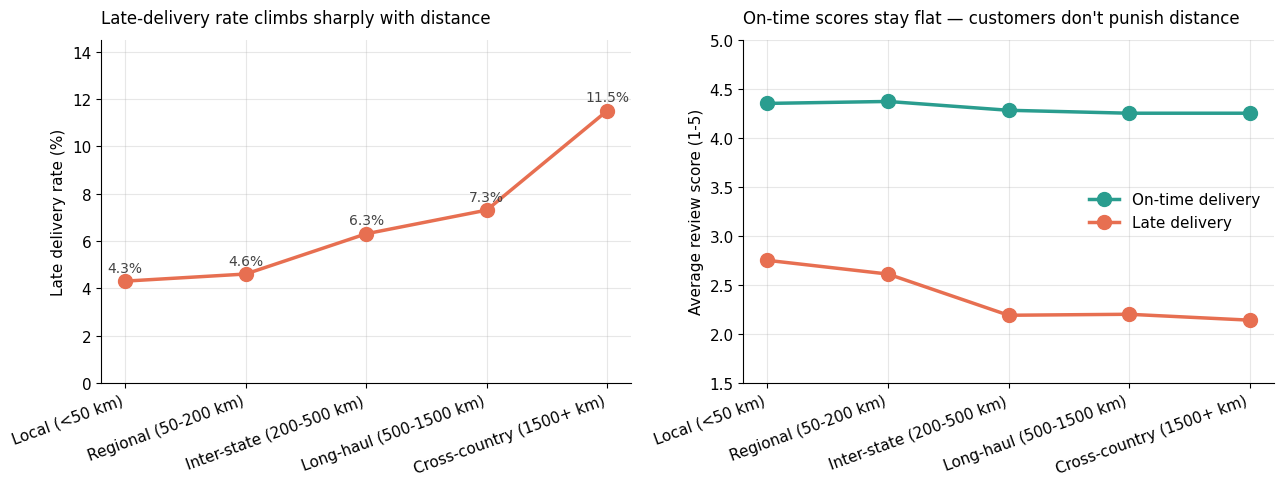

In [9]:
# Two-panel chart: left shows that late-rate climbs with distance
# (the mechanical effect), right shows that on-time scores stay flat
# while late scores fall (the customer-fairness finding).

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

short_labels = [b.split(". ", 1)[1] for b in df3["distance_bucket"]]

ax1.plot(
    short_labels,
    df3["pct_late"],
    marker="o",
    markersize=10,
    linewidth=2.5,
    color="#e76f51",
)
for i, v in enumerate(df3["pct_late"]):
    ax1.text(i, v + 0.4, f"{v:.1f}%", ha="center", fontsize=10, color="#444")

ax1.set_ylabel("Late delivery rate (%)")
ax1.set_ylim(0, max(df3["pct_late"]) + 3)
ax1.set_title("Late-delivery rate climbs sharply with distance",
              fontsize=12, pad=12, loc="left")
ax1.tick_params(axis="x", rotation=20)
for label in ax1.get_xticklabels():
    label.set_horizontalalignment("right")

ax2.plot(
    short_labels,
    df3["avg_score_ontime"],
    marker="o",
    markersize=10,
    linewidth=2.5,
    color="#2a9d8f",
    label="On-time delivery",
)
ax2.plot(
    short_labels,
    df3["avg_score_late"],
    marker="o",
    markersize=10,
    linewidth=2.5,
    color="#e76f51",
    label="Late delivery",
)

ax2.set_ylabel("Average review score (1-5)")
ax2.set_ylim(1.5, 5)
ax2.set_title("On-time scores stay flat — customers don't punish distance",
              fontsize=12, pad=12, loc="left")
ax2.legend(loc="center right", frameon=False)
ax2.tick_params(axis="x", rotation=20)
for label in ax2.get_xticklabels():
    label.set_horizontalalignment("right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_distance_confounder.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:** Distance is a confounder, not a direct cause. On time deliveries score nearly identically regardless of shipping distance (4.25 vs 4.35). Customers respond to outcomes, not geography.

## 4. Does seller size protect against the late-delivery penalty?

We hypothesised that customers would extend more goodwill to large, high-volume sellers when deliveries went wrong, that brand familiarity (proxied by total order volume on Olist) would buffer sellers from review damage. To test it, we tier sellers into Small (<20 lifetime orders), Mid (20-199), and Large (200+) and compare the on-time vs late score gap within each tier.

The result is a **null finding**: the score penalty for a late delivery is essentially identical across all three tiers (≈ 2 stars). Customers respond to outcomes, not to seller reputation. The implication for Olist is concrete: investing in seller-tier badges or trust signals would not protect sellers from late-delivery review damage. The only intervention that helps is delivering on time.

A secondary observation worth noting: 91 large sellers (3% of the seller base) handle nearly as many orders as the 2,138 small sellers combined. The marketplace exhibits the heavy-tailed concentration typical of e-commerce platforms, but tier doesn't translate into customer-perception advantages.

In [10]:
df4 = run_query("04_seller_size_interaction.sql")
df4

,size_tier,n_sellers,n_ontime,n_late,pct_late,avg_score_ontime,avg_score_late,score_drop_when_late
0,1. Small (<20 orders),2138,10703,755,6.6,4.35,2.35,1.99
1,2. Mid (20-199 orders),727,39965,2694,6.3,4.30,2.27,2.03
2,3. Large (200+ orders),91,39276,2960,7.0,4.26,2.25,2.01


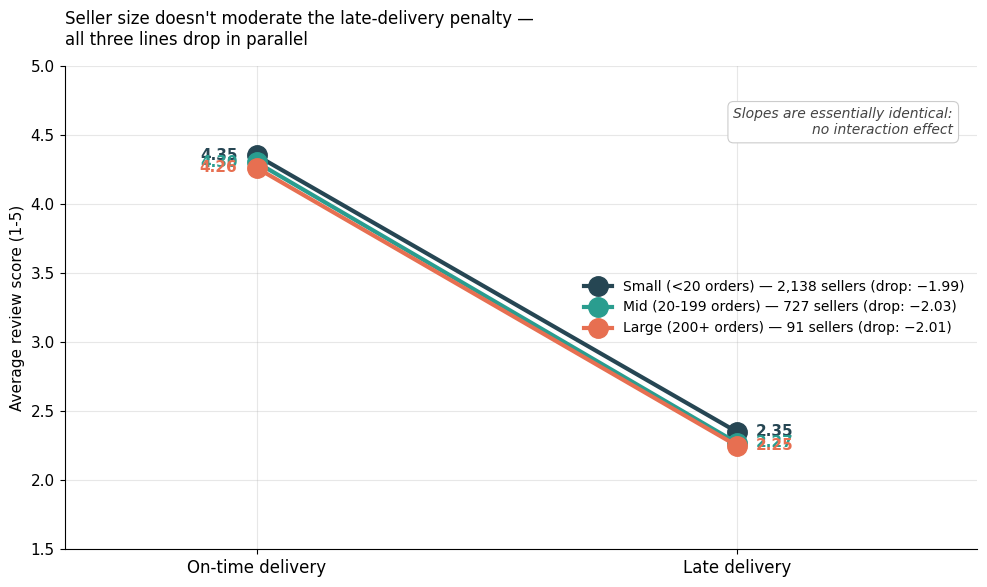

In [12]:
# Slopegraph: three lines, one per seller tier, each connecting
# on-time score to late score. The visual signature of "no
# interaction effect" is parallel slopes, the chart's job is
# to make that parallelism immediately undeniable.

fig, ax = plt.subplots(figsize=(10, 6))

x_positions = [0, 1]
tier_colors = {
    "1. Small (<20 orders)": "#264653",
    "2. Mid (20-199 orders)": "#2a9d8f",
    "3. Large (200+ orders)": "#e76f51",
}

for _, row in df4.iterrows():
    tier = row["size_tier"]
    ontime = row["avg_score_ontime"]
    late = row["avg_score_late"]
    drop = row["score_drop_when_late"]
    n_sellers = row["n_sellers"]

    ax.plot(
        x_positions,
        [ontime, late],
        marker="o",
        markersize=14,
        linewidth=3,
        color=tier_colors[tier],
        label=f"{tier[3:]} — {n_sellers:,} sellers (drop: −{drop:.2f})",
    )

    # Score values at each endpoint, colour-matched to the line
    ax.text(
        x_positions[0] - 0.04, ontime, f"{ontime:.2f}",
        ha="right", va="center",
        fontsize=11, color=tier_colors[tier], fontweight="bold",
    )
    ax.text(
        x_positions[1] + 0.04, late, f"{late:.2f}",
        ha="left", va="center",
        fontsize=11, color=tier_colors[tier], fontweight="bold",
    )

ax.set_xticks(x_positions)
ax.set_xticklabels(["On-time delivery", "Late delivery"], fontsize=12)
ax.set_xlim(-0.4, 1.5)
ax.set_ylim(1.5, 5)
ax.set_ylabel("Average review score (1-5)")
ax.set_title(
    "Seller size doesn't moderate the late-delivery penalty —\nall three lines drop in parallel",
    fontsize=12, pad=15, loc="left",
)
ax.legend(loc="center right", frameon=False, fontsize=10)

# Subtle annotation reinforcing the null finding
ax.annotate(
    "Slopes are essentially identical:\nno interaction effect",
    xy=(1.45, 4.7),
    fontsize=10,
    color="#444",
    ha="right",
    va="top",
    style="italic",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#ccc", linewidth=0.8),
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_seller_size_null.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding (null result):** Seller size does not moderate the late delivery penalty. The score drop is roughly 2 stars across all three seller tiers. Brand familiarity does not buy a buffer against bad delivery experiences.

## 5. Where should Olist focus delivery improvements?

Combining the findings from sub-questions 1-4, we compute a prioritised list of (category, customer state) combinations ranked by the total review-score points recoverable if late deliveries in that segment became on-time. The metric weights effect size by volume, so the ranking surfaces segments where the most aggregate customer satisfaction is being lost.

The result reveals **two structurally different intervention archetypes**, which a single ranked list would have hidden:

- **Rio de Janeiro: a quality-of-service problem.** RJ deliveries are 3-4× more likely to be late than São Paulo's across every category, despite being Brazil's second-largest economy. The per-order penalty when things go wrong is also high, especially in time-sensitive categories. This pattern points to a systemic infrastructure issue, a specific carrier, distribution node, or last-mile arrangement that's underperforming.

- **São Paulo: a scale-driven optimisation.** SP already operates well (4-5% late rates), but the volume is so large that even small improvements compound into hundreds of recovered review points across the customer base. This is operational tuning, not rescue.

Different teams, different timelines, different success metrics. A naive single-priority ranking would have framed these as "do RJ first, then SP", but they aren't comparable interventions, and the chart below makes the distinction physical.

In [13]:
df5 = run_query("05_intervention_priorities.sql")
df5

,category,customer_state,n_orders,pct_late,avg_score_ontime,avg_score_late,avg_score_current,avg_score_potential,score_uplift_potential,total_review_points_recoverable
0,bed_bath_table,RJ,1329,15.0,4.11,1.98,3.79,4.11,0.32,427.0
1,health_beauty,SP,3691,5.3,4.42,2.76,4.33,4.42,0.09,328.0
2,bed_bath_table,SP,4310,4.0,4.22,2.48,4.15,4.22,0.07,300.0
3,sports_leisure,RJ,890,13.8,4.29,1.88,3.95,4.29,0.33,296.0
4,sports_leisure,SP,3207,4.3,4.41,2.43,4.32,4.41,0.09,273.0
5,computers_accessories,RJ,825,11.9,4.23,1.73,3.94,4.23,0.30,245.0
6,housewares,SP,2687,4.0,4.37,2.26,4.29,4.37,0.08,226.0
7,watches_gifts,RJ,773,13.8,4.18,2.07,3.88,4.18,0.29,226.0
8,furniture_decor,SP,2642,4.7,4.25,2.42,4.17,4.25,0.09,225.0
9,furniture_decor,RJ,814,11.9,4.09,1.90,3.83,4.09,0.26,213.0


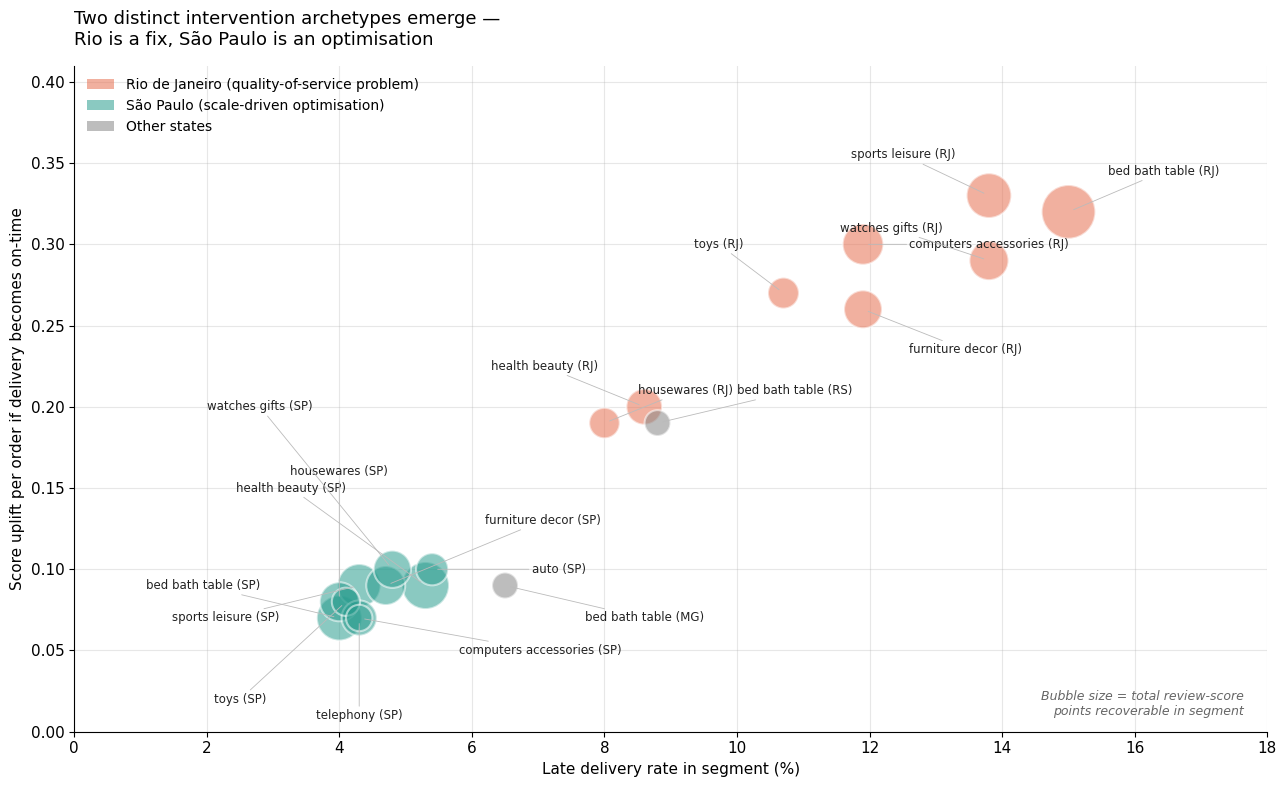

In [ ]:
# Bubble scatter: x-axis is the problem (late-rate), y-axis is
# the cost per order (uplift potential), bubble size is the prize
# (total recoverable review points). The two intervention
# archetypes — Rio's quality-of-service crisis and São Paulo's
# scale optimisation — should physically cluster in different
# regions of the plot.

fig, ax = plt.subplots(figsize=(13, 8))

state_colors = {
    "RJ": "#e76f51",
    "SP": "#2a9d8f",
}
default_color = "#888"

colors = [state_colors.get(s, default_color) for s in df5["customer_state"]]
sizes = df5["total_review_points_recoverable"] * 3.5

ax.scatter(
    df5["pct_late"],
    df5["score_uplift_potential"],
    s=sizes,
    c=colors,
    alpha=0.55,
    edgecolors="white",
    linewidth=1.5,
    zorder=2,
)

# Manual label offsets per row, tuned to spread the SP cluster.
# Each entry is (dx, dy) in axes-data units, applied to the bubble
# centre to position the text. Hand-tuning is faster as writing an
# algorithm would be overkill
label_offsets = {
    ("bed_bath_table", "RJ"):           (0.6,  0.025, "left"),
    ("sports_leisure", "RJ"):           (-0.5, 0.025, "right"),
    ("computers_accessories", "RJ"):    (0.7,  0.000, "left"),
    ("watches_gifts", "RJ"):            (-0.7, 0.020, "right"),
    ("furniture_decor", "RJ"):          (0.7, -0.025, "left"),
    ("toys", "RJ"):                     (-0.6, 0.030, "right"),
    ("health_beauty", "RJ"):            (-0.7, 0.025, "right"),

    ("bed_bath_table", "MG"):           (1.2, -0.020, "left"),
    ("bed_bath_table", "RS"):           (1.2,  0.020, "left"),

    ("health_beauty", "SP"):            (-1.2, 0.060, "right"),
    ("bed_bath_table", "SP"):           (-1.2, 0.020, "right"),
    ("sports_leisure", "SP"):           (-1.2, -0.020, "right"),
    ("housewares", "SP"):               (0.0,  0.080, "center"),
    ("furniture_decor", "SP"):          (1.5,  0.040, "left"),
    ("watches_gifts", "SP"):            (-1.2, 0.100, "right"),
    ("computers_accessories", "SP"):    (1.5, -0.020, "left"),
    ("auto", "SP"):                     (1.5,  0.000, "left"),
    ("toys", "SP"):                     (-1.2, -0.060, "right"),
    ("telephony", "SP"):                (0.0, -0.060, "center"),
}

for _, row in df5.iterrows():
    key = (row["category"], row["customer_state"])
    dx, dy, ha = label_offsets.get(key, (0.5, 0.020, "left"))
    label_x = row["pct_late"] + dx
    label_y = row["score_uplift_potential"] + dy

    label = f"{row['category'].replace('_', ' ')} ({row['customer_state']})"

    # Thin connector line from bubble centre to label
    ax.annotate(
        label,
        xy=(row["pct_late"], row["score_uplift_potential"]),
        xytext=(label_x, label_y),
        ha=ha,
        va="center",
        fontsize=8.5,
        color="#222",
        arrowprops=dict(
            arrowstyle="-",
            color="#bbb",
            lw=0.6,
            shrinkA=0,
            shrinkB=4,
        ),
        zorder=3,
    )

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#e76f51", alpha=0.55, label="Rio de Janeiro (quality-of-service problem)"),
    Patch(facecolor="#2a9d8f", alpha=0.55, label="São Paulo (scale-driven optimisation)"),
    Patch(facecolor="#888", alpha=0.55, label="Other states"),
]
ax.legend(handles=legend_elements, loc="upper left", frameon=False, fontsize=10)

ax.annotate(
    "Bubble size = total review-score\npoints recoverable in segment",
    xy=(0.98, 0.02),
    xycoords="axes fraction",
    ha="right",
    va="bottom",
    fontsize=9,
    color="#666",
    style="italic",
)

ax.set_xlabel("Late delivery rate in segment (%)")
ax.set_ylabel("Score uplift per order if delivery becomes on-time")
ax.set_title(
    "Two distinct intervention archetypes emerge —\nRio is a fix, São Paulo is an optimisation",
    fontsize=13, pad=15, loc="left",
)
ax.set_xlim(0, max(df5["pct_late"]) + 3)
ax.set_ylim(0, max(df5["score_uplift_potential"]) + 0.08)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_intervention_priorities.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:** The priority list splits into two structurally different intervention types. Rio de Janeiro segments need a logistics fix (high late-rates, high per-order penalty). São Paulo segments offer scale driven gains (low late-rates, but enormous volume).

## Findings and Recommendations

### Headline Finding

Crossing Olist's estimated delivery date by even a single day costs sellers an average of **1.4 stars** on customer reviews, the steepest single drop in the entire analysis. Late deliveries account for 41% of all 1-star reviews in the dataset despite representing only 7% of delivered orders. Delivery performance is the dominant lever on customer satisfaction, ahead of category, geography, or seller identity.

### Five Findings, in Order

1. **The penalty is sharply non-linear.** Early and on-time deliveries cluster around 4.1 to 4.3 stars; the moment a delivery crosses its estimated date, the average score falls to 2.7, and severely late orders (8-30 days) collapse to 1.7. The cliff is at zero, not at "very late."

2. **Categories differ in how harshly they punish lateness, by up to 28%.** Time-sensitive emotional purchases (toys, sports equipment, gifts) show late-delivery penalties of 2.0+ stars. Routine household categories like telephony, furniture, and bedding sit closer to 1.75. The mechanism is plausibly the emotional stakes attached to the purchase: a missed birthday gift can never be un-missed.

3. **Distance is a confounder, not a cause.** Long-distance deliveries are 3x more likely to be late than local ones, but on-time deliveries score nearly identically (4.25 vs 4.35) regardless of distance. Customers respond to outcomes, not to seller geography. The disadvantage long-distance sellers face is a logistics problem, not a fairness problem.

4. **Seller size doesn't moderate the penalty (null result).** We hypothesised that customers would extend goodwill to high-volume "trusted" sellers when deliveries went wrong. The data doesn't support this. Late deliveries cost roughly 2 stars regardless of whether the seller has shipped 5 orders or 5,000. Brand familiarity, at least as proxied by order volume, doesn't buy a buffer against bad delivery experiences.

5. **Two distinct intervention archetypes dominate the priority list.** Rio de Janeiro segments show structurally elevated late-rates (3-4x São Paulo's) coupled with high per-order penalty, suggesting a systemic infrastructure issue. São Paulo segments are already operating well but offer scale-driven gains via incremental improvements across high-volume categories. These are not interchangeable interventions and shouldn't be ranked against each other.

### Recommendations for Olist

Three concrete moves, in priority order:

1. **Investigate the Rio de Janeiro logistics gap.** RJ's late-rate is structurally 3-4x higher than São Paulo's across every category in the top 10. This is too uniform across categories to be a category-specific issue and too large to be noise. The likely culprits are infrastructure: a specific carrier contract, a bottlenecked distribution node, or a last-mile arrangement that needs renegotiating. Closing this gap is the single highest-leverage delivery intervention in the dataset.

2. **Set category-aware delivery estimates.** Olist already over-promises delivery time conservatively (the modal order arrives around 13 days *before* the estimate). The data suggests this buffer should be even larger for emotional or gift categories like toys, watches, and sports equipment, where the penalty for slipping is steepest. The current uniform-buffer approach leaves predictable review damage on the table.

3. **De-prioritise seller-tier badges or trust signals as a delivery-defence mechanism.** The null result in section 4 is direct evidence that customer goodwill toward known sellers doesn't survive a bad delivery experience. Investment in these signals is fine for other reasons (discoverability, conversion), but shouldn't be justified as protecting sellers from late-delivery review damage.

### Limitations

The analysis has two material limitations worth stating explicitly:

- **Correlational, not causal.** This analysis can't rule out that customers who buy time-sensitive categories are also systematically more demanding reviewers across all dimensions, or that long-distance shoppers self-select in ways that affect baseline expectations. A controlled experiment varying delivery promises within a single category-state combination would isolate the effects more cleanly.

- **Binary on-time/late simplification.** Most of the analysis collapses delivery delay into a two-state variable (on-time-or-early vs late). This loses information about delay magnitude, which we know matters from sub-question 1: a delivery 30 days late is a different event from one 1 day late. Future work could re-run sub-questions 2-5 with a continuous delay variable and report effect sizes per additional day late.

Smaller caveats: roughly 600 orders (under 1% of the delivered population) were excluded from the distance analysis due to missing geolocation entries. The category attribution uses the first item per order, which is a defensible simplification but does miss multi-category basket effects. The "very late" bucket (30+ days, n=331) shows an anomalously higher average score than the moderately-late bucket; we believe this reflects category mix in that tail (long delays skew toward forgiving categories like furniture) but didn't formally test it.

### Reproducing This Analysis

The full project (SQL queries, this notebook, the figures) is structured to be reproducible. Clone the repository, follow `data/README.md` to download the Olist SQLite database, run `setup/01_create_indexes.sql` once to create join-key indexes, then execute the notebook. Total runtime on a laptop is under a minute.